In [1]:
1+1

2

In [2]:
import os

# Specify the folder path
folder_path = r'F:\MLpractrice\stockmarket\work'

# List all files in the folder
files = os.listdir(folder_path)

# Print the list of files
for file in files:
    if os.path.isfile(os.path.join(folder_path, file)):
        print(file)


DSE_STOCKS_20230101.csv
DSE_STOCKS_20230131.csv


In [3]:
import pandas as pd

# File paths
file_1 = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_20230101.csv'
file_2 = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_20230131.csv'

# Load the data into pandas DataFrames
data_1 = pd.read_csv(file_1)
data_2 = pd.read_csv(file_2)

# Display the first few rows of each DataFrame
print("Data from 2023-01-01:")
print(data_1.head())

print("\nData from 2023-01-31:")
print(data_2.head())


Data from 2023-01-01:
       Date       Scrip        Open        High         Low       Close  \
0  20230101      00DS30  2195.30158  2205.14579  2192.68497  2193.60229   
1  20230101      00DSES  1358.83640  1365.93691  1355.43267  1355.59149   
2  20230101      00DSEX  6206.81389  6222.89281  6194.37735  6195.37281   
3  20230101  1STPRIMFMF    16.40000    16.40000    16.40000    16.40000   
4  20230101    AAMRANET    52.80000    52.80000    49.70000    50.30000   

       Volume  
0  1784259000  
1  1784259000  
2  1784259000  
3         512  
4     1051934  

Data from 2023-01-31:
       Date       Scrip        Open        High         Low       Close  \
0  20230131      00DS30  2225.83157  2231.74488  2216.55109  2219.59862   
1  20230131      00DSES  1370.26977  1372.83620  1364.15880  1366.00826   
2  20230131      00DSEX  6278.84113  6285.89627  6264.82880  6267.05466   
3  20230131  1STPRIMFMF    14.70000    14.70000    14.60000    14.60000   
4  20230131    AAMRANET    68.000

In [4]:
import pandas as pd

# File paths
file_1 = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_20230101.csv'
file_2 = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_20230131.csv'

# Load the data into pandas DataFrames
data_1 = pd.read_csv(file_1)
data_2 = pd.read_csv(file_2)

# List of Scrip values to remove
scrip_to_remove = ['00DS30', '00DSES', '00DSEX']

# Remove rows where the Scrip value is in the scrip_to_remove list
data_1_cleaned = data_1[~data_1['Scrip'].isin(scrip_to_remove)]
data_2_cleaned = data_2[~data_2['Scrip'].isin(scrip_to_remove)]

# Optional: Save the cleaned data back to CSV
data_1_cleaned.to_csv(r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_20230101_cleaned.csv', index=False)
data_2_cleaned.to_csv(r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_20230131_cleaned.csv', index=False)

# Display the cleaned data
print("Cleaned Data from 2023-01-01:")
print(data_1_cleaned.head())

print("\nCleaned Data from 2023-01-31:")
print(data_2_cleaned.head())


Cleaned Data from 2023-01-01:
       Date       Scrip  Open  High   Low  Close   Volume
3  20230101  1STPRIMFMF  16.4  16.4  16.4   16.4      512
4  20230101    AAMRANET  52.8  52.8  49.7   50.3  1051934
5  20230101   AAMRATECH  40.5  41.1  38.9   39.0   289417
6  20230101    ABB1STMF   5.2   5.2   5.2    5.2      648
7  20230101      ABBANK   9.9   9.9   9.9    9.9     1681

Cleaned Data from 2023-01-31:
       Date       Scrip  Open  High   Low  Close   Volume
3  20230131  1STPRIMFMF  14.7  14.7  14.6   14.6    79116
4  20230131    AAMRANET  68.0  68.4  66.4   67.3  3041442
5  20230131   AAMRATECH  36.7  36.7  35.2   35.3   781597
6  20230131      ABBANK   9.9   9.9   9.9    9.9     5696
7  20230131        ACFL  26.5  26.5  26.5   26.5      250


In [5]:
import pandas as pd

# File paths for cleaned data
file_1_cleaned = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_20230101_cleaned.csv'
file_2_cleaned = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_20230131_cleaned.csv'

# Load the cleaned data into pandas DataFrames
data_1_cleaned = pd.read_csv(file_1_cleaned)
data_2_cleaned = pd.read_csv(file_2_cleaned)

# Merge the two DataFrames on the 'Scrip' column
merged_data = pd.merge(data_1_cleaned[['Scrip', 'Close']], data_2_cleaned[['Scrip', 'Close']], on='Scrip', suffixes=('_01', '_31'))

# Create the 'UpDown' column based on the comparison of closing prices
merged_data['UpDown'] = merged_data['Close_31'] > merged_data['Close_01']
merged_data['UpDown'] = merged_data['UpDown'].replace({True: 'Up', False: 'Down'})

# Save the merged data to a new CSV file
merged_data.to_csv(r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_merged.csv', index=False)

# Display the first few rows of the merged data
print("Merged Data with UpDown Column:")
print(merged_data.head())


Merged Data with UpDown Column:
        Scrip  Close_01  Close_31 UpDown
0  1STPRIMFMF      16.4      14.6   Down
1    AAMRANET      50.3      67.3     Up
2   AAMRATECH      39.0      35.3   Down
3      ABBANK       9.9       9.9   Down
4        ACFL      26.5      26.5   Down


In [6]:
import pandas as pd

# File paths for cleaned data
file_1_cleaned = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_20230101_cleaned.csv'
file_2_cleaned = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_20230131_cleaned.csv'

# Load the cleaned data into pandas DataFrames
data_1_cleaned = pd.read_csv(file_1_cleaned)
data_2_cleaned = pd.read_csv(file_2_cleaned)

# Merge the two DataFrames on the 'Scrip' column
merged_data = pd.merge(data_1_cleaned, data_2_cleaned, on='Scrip', suffixes=('_01', '_31'))

# Save the merged data to a new CSV file
merged_data.to_csv(r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_merged.csv', index=False)

# Display the first few rows of the merged data
print("Merged Data:")
print(merged_data.head())


Merged Data:
    Date_01       Scrip  Open_01  High_01  Low_01  Close_01  Volume_01  \
0  20230101  1STPRIMFMF     16.4     16.4    16.4      16.4        512   
1  20230101    AAMRANET     52.8     52.8    49.7      50.3    1051934   
2  20230101   AAMRATECH     40.5     41.1    38.9      39.0     289417   
3  20230101      ABBANK      9.9      9.9     9.9       9.9       1681   
4  20230101        ACFL     26.5     26.5    26.5      26.5        101   

    Date_31  Open_31  High_31  Low_31  Close_31  Volume_31  
0  20230131     14.7     14.7    14.6      14.6      79116  
1  20230131     68.0     68.4    66.4      67.3    3041442  
2  20230131     36.7     36.7    35.2      35.3     781597  
3  20230131      9.9      9.9     9.9       9.9       5696  
4  20230131     26.5     26.5    26.5      26.5        250  


In [7]:
import pandas as pd

# File paths for cleaned data
file_1_cleaned = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_20230101_cleaned.csv'
file_2_cleaned = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_20230131_cleaned.csv'

# Load the cleaned data into pandas DataFrames
data_1_cleaned = pd.read_csv(file_1_cleaned)
data_2_cleaned = pd.read_csv(file_2_cleaned)

# Merge the two DataFrames on the 'Scrip' column
merged_data = pd.merge(data_1_cleaned, data_2_cleaned, on='Scrip', suffixes=('_01', '_31'))

# Create a new DataFrame to hold the merged values in a unified format
final_data = pd.DataFrame()

# For each relevant column, combine values from both files into a single column
columns = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in columns:
    final_data[col] = merged_data[f'{col}_01'].astype(str) + ' / ' + merged_data[f'{col}_31'].astype(str)

# Add the 'Scrip' column to the final data
final_data['Scrip'] = merged_data['Scrip']

# Save the final merged data to a new CSV file
final_data.to_csv(r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_merged_final.csv', index=False)

# Display the first few rows of the final data
print("Final Merged Data with Unified Columns:")
print(final_data.head())


Final Merged Data with Unified Columns:
          Open         High          Low        Close             Volume  \
0  16.4 / 14.7  16.4 / 14.7  16.4 / 14.6  16.4 / 14.6        512 / 79116   
1  52.8 / 68.0  52.8 / 68.4  49.7 / 66.4  50.3 / 67.3  1051934 / 3041442   
2  40.5 / 36.7  41.1 / 36.7  38.9 / 35.2  39.0 / 35.3    289417 / 781597   
3    9.9 / 9.9    9.9 / 9.9    9.9 / 9.9    9.9 / 9.9        1681 / 5696   
4  26.5 / 26.5  26.5 / 26.5  26.5 / 26.5  26.5 / 26.5          101 / 250   

        Scrip  
0  1STPRIMFMF  
1    AAMRANET  
2   AAMRATECH  
3      ABBANK  
4        ACFL  


In [9]:
import pandas as pd

# File paths for cleaned data
file_1_cleaned = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_20230101_cleaned.csv'
file_2_cleaned = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_20230131_cleaned.csv'

# Load the cleaned data into pandas DataFrames
data_1_cleaned = pd.read_csv(file_1_cleaned)
data_2_cleaned = pd.read_csv(file_2_cleaned)

# Merge the two DataFrames on the 'Scrip' column
merged_data = pd.merge(data_1_cleaned, data_2_cleaned, on='Scrip', suffixes=('_01', '_31'))

# Save the merged data to a new CSV file with separate columns for both dates
merged_data.to_csv(r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_merged_final_separated.csv', index=False)

# Display the first few rows of the merged data
print("Merged Data with Separate Columns for Both Dates:")
print(merged_data.head())


Merged Data with Separate Columns for Both Dates:
    Date_01       Scrip  Open_01  High_01  Low_01  Close_01  Volume_01  \
0  20230101  1STPRIMFMF     16.4     16.4    16.4      16.4        512   
1  20230101    AAMRANET     52.8     52.8    49.7      50.3    1051934   
2  20230101   AAMRATECH     40.5     41.1    38.9      39.0     289417   
3  20230101      ABBANK      9.9      9.9     9.9       9.9       1681   
4  20230101        ACFL     26.5     26.5    26.5      26.5        101   

    Date_31  Open_31  High_31  Low_31  Close_31  Volume_31  
0  20230131     14.7     14.7    14.6      14.6      79116  
1  20230131     68.0     68.4    66.4      67.3    3041442  
2  20230131     36.7     36.7    35.2      35.3     781597  
3  20230131      9.9      9.9     9.9       9.9       5696  
4  20230131     26.5     26.5    26.5      26.5        250  


In [10]:
import pandas as pd

# File paths for cleaned data
file_1_cleaned = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_20230101_cleaned.csv'
file_2_cleaned = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_20230131_cleaned.csv'

# Load the cleaned data into pandas DataFrames
data_1_cleaned = pd.read_csv(file_1_cleaned)
data_2_cleaned = pd.read_csv(file_2_cleaned)

# Merge the two DataFrames on the 'Scrip' column
merged_data = pd.merge(data_1_cleaned, data_2_cleaned, on='Scrip', suffixes=('_01', '_31'))

# Create an empty list to store the reordered rows
final_data = []

# Loop through each row of the merged data and rearrange
for index, row in merged_data.iterrows():
    # First, append the row for January 31st data
    row_31 = row[['Scrip', 'Open_31', 'High_31', 'Low_31', 'Close_31', 'Volume_31']].copy()
    row_31['Date'] = '2023-01-31'
    final_data.append(row_31)
    
    # Then, append the row for January 1st data
    row_01 = row[['Scrip', 'Open_01', 'High_01', 'Low_01', 'Close_01', 'Volume_01']].copy()
    row_01['Date'] = '2023-01-01'
    final_data.append(row_01)

# Convert the final list of rows into a DataFrame
final_df = pd.DataFrame(final_data)

# Save the final merged data to a new CSV file
final_df.to_csv(r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_merged_final_ordered.csv', index=False)

# Display the first few rows of the final data
print("Final Merged Data with 31st Date First for Each Scrip:")
print(final_df.head())


Final Merged Data with 31st Date First for Each Scrip:
        Scrip  Open_31  High_31  Low_31  Close_31  Volume_31        Date  \
0  1STPRIMFMF     14.7     14.7    14.6      14.6    79116.0  2023-01-31   
0  1STPRIMFMF      NaN      NaN     NaN       NaN        NaN  2023-01-01   
1    AAMRANET     68.0     68.4    66.4      67.3  3041442.0  2023-01-31   
1    AAMRANET      NaN      NaN     NaN       NaN        NaN  2023-01-01   
2   AAMRATECH     36.7     36.7    35.2      35.3   781597.0  2023-01-31   

   Open_01  High_01  Low_01  Close_01  Volume_01  
0      NaN      NaN     NaN       NaN        NaN  
0     16.4     16.4    16.4      16.4      512.0  
1      NaN      NaN     NaN       NaN        NaN  
1     52.8     52.8    49.7      50.3  1051934.0  
2      NaN      NaN     NaN       NaN        NaN  


In [14]:
import pandas as pd

# File paths for cleaned data
file_1_cleaned = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_20230101_cleaned.csv'
file_2_cleaned = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_20230131_cleaned.csv'

# Load the cleaned data into pandas DataFrames
data_1_cleaned = pd.read_csv(file_1_cleaned)
data_2_cleaned = pd.read_csv(file_2_cleaned)

# Merge the two DataFrames on the 'Scrip' column
merged_data = pd.merge(data_1_cleaned, data_2_cleaned, on='Scrip', suffixes=('_01', '_31'))

# Create an empty list to store the reordered rows
final_data = []

# Loop through each row of the merged data and rearrange
for index, row in merged_data.iterrows():
    # First, append the row for January 31st data
    row_31 = pd.DataFrame([row[['Scrip', 'Open_31', 'High_31', 'Low_31', 'Close_31', 'Volume_31']].values], 
                          columns=['Scrip', 'Open', 'High', 'Low', 'Close', 'Volume'])
    row_31['Date'] = '2023-01-31'
    final_data.append(row_31)
    
    # Then, append the row for January 1st data
    row_01 = pd.DataFrame([row[['Scrip', 'Open_01', 'High_01', 'Low_01', 'Close_01', 'Volume_01']].values], 
                          columns=['Scrip', 'Open', 'High', 'Low', 'Close', 'Volume'])
    row_01['Date'] = '2023-01-01'
    final_data.append(row_01)

# Concatenate all the individual DataFrames into a single DataFrame
final_df = pd.concat(final_data, ignore_index=True)

# Save the final merged data to a new CSV file
final_df.to_csv(r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_merged_final_ordered.csv', index=False)

# Display the first few rows of the final data
print("Final Merged Data with 31st Date First for Each Scrip:")
print(final_df.head())


Final Merged Data with 31st Date First for Each Scrip:
        Scrip  Open  High   Low  Close   Volume        Date
0  1STPRIMFMF  14.7  14.7  14.6   14.6    79116  2023-01-31
1  1STPRIMFMF  16.4  16.4  16.4   16.4      512  2023-01-01
2    AAMRANET  68.0  68.4  66.4   67.3  3041442  2023-01-31
3    AAMRANET  52.8  52.8  49.7   50.3  1051934  2023-01-01
4   AAMRATECH  36.7  36.7  35.2   35.3   781597  2023-01-31


In [15]:
import pandas as pd
import numpy as np

# Load the merged data file
file_path = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_merged_final_ordered.csv'
merged_data = pd.read_csv(file_path)

# Step 1: Remove duplicates
merged_data = merged_data.drop_duplicates()

# Step 2: Handle missing values
# Let's check for missing values
missing_values = merged_data.isnull().sum()
print("Missing values before cleaning:")
print(missing_values)

# Drop rows with missing target values (if any)
merged_data = merged_data.dropna(subset=['Scrip', 'Open', 'High', 'Low', 'Close', 'Volume'])

# Alternatively, you can forward fill missing values:
# merged_data.fillna(method='ffill', inplace=True)

# Step 3: Convert 'Date' columns to datetime (if not already done)
merged_data['Date'] = pd.to_datetime(merged_data['Date'], format='%Y-%m-%d')

# Step 4: Feature Engineering
# Add 'Price Change' for each day (difference between consecutive closes)
merged_data['Price_Change'] = merged_data['Close'].diff()

# Add moving averages (e.g., 7-day moving average for Close prices)
merged_data['MA_7'] = merged_data['Close'].rolling(window=7).mean()

# Add Percentage Change (how much the close price changed between dates)
merged_data['Pct_Change'] = merged_data['Close'].pct_change() * 100

# Step 5: Remove Outliers (optional)
# For example, remove rows with volume higher than the 99th percentile
merged_data = merged_data[merged_data['Volume'] < merged_data['Volume'].quantile(0.99)]

# Step 6: Reset index (optional)
merged_data.reset_index(drop=True, inplace=True)

# Step 7: Check for any remaining missing values
missing_values_after = merged_data.isnull().sum()
print("\nMissing values after cleaning:")
print(missing_values_after)

# Step 8: Save the cleaned data to a new CSV file
cleaned_file_path = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_merged_final_cleaned.csv'
merged_data.to_csv(cleaned_file_path, index=False)

# Display the cleaned data preview
print("\nCleaned Data Preview:")
print(merged_data.head())


Missing values before cleaning:
Scrip     0
Open      0
High      0
Low       0
Close     0
Volume    0
Date      0
dtype: int64

Missing values after cleaning:
Scrip           0
Open            0
High            0
Low             0
Close           0
Volume          0
Date            0
Price_Change    1
MA_7            5
Pct_Change      1
dtype: int64

Cleaned Data Preview:
        Scrip  Open  High   Low  Close   Volume       Date  Price_Change  \
0  1STPRIMFMF  14.7  14.7  14.6   14.6    79116 2023-01-31           NaN   
1  1STPRIMFMF  16.4  16.4  16.4   16.4      512 2023-01-01           1.8   
2    AAMRANET  52.8  52.8  49.7   50.3  1051934 2023-01-01         -17.0   
3   AAMRATECH  36.7  36.7  35.2   35.3   781597 2023-01-31         -15.0   
4   AAMRATECH  40.5  41.1  38.9   39.0   289417 2023-01-01           3.7   

   MA_7  Pct_Change  
0   NaN         NaN  
1   NaN   12.328767  
2   NaN  -25.260030  
3   NaN  -29.821074  
4   NaN   10.481586  


In [17]:
import pandas as pd
import numpy as np

# Load the merged data file
file_path = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_merged_final_ordered.csv'
merged_data = pd.read_csv(file_path)

# Step 1: Remove duplicates
merged_data = merged_data.drop_duplicates()

# Step 2: Convert 'Date' columns to datetime (if not already done)
merged_data['Date'] = pd.to_datetime(merged_data['Date'], format='%Y-%m-%d')

# Step 3: Feature Engineering (add Price Change, Moving Average, and Percentage Change)
# Add 'Price Change' for each day (difference between consecutive closes)
merged_data['Price_Change'] = merged_data['Close'].diff()

# Add moving averages (e.g., 7-day moving average for Close prices)
merged_data['MA_7'] = merged_data['Close'].rolling(window=7).mean()

# Add Percentage Change (how much the close price changed between dates)
merged_data['Pct_Change'] = merged_data['Close'].pct_change() * 100

# Step 4: Handle missing values for created features
# Fill NaN values in Price Change with 0 (you can choose any other strategy like forward fill)
merged_data['Price_Change'].fillna(0, inplace=True)

# Fill NaN values in MA_7 (you can leave NaN or use a rolling window with a smaller size if needed)
merged_data['MA_7'].fillna(method='ffill', inplace=True)  # Forward fill as an example

# Fill NaN values in Pct_Change (you can leave NaN or use forward fill)
merged_data['Pct_Change'].fillna(0, inplace=True)  # Or use ffill(), depending on your choice

# Step 5: Reset index (optional)
merged_data.reset_index(drop=True, inplace=True)

# Step 6: Save the cleaned data to a new CSV file
cleaned_file_path = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_merged_final_cleaned_filled.csv'
merged_data.to_csv(cleaned_file_path, index=False)

# Display the cleaned data preview
print("\nCleaned Data Preview with Filled Missing Values:")
print(merged_data.head())



Cleaned Data Preview with Filled Missing Values:
        Scrip  Open  High   Low  Close   Volume       Date  Price_Change  \
0  1STPRIMFMF  14.7  14.7  14.6   14.6    79116 2023-01-31           0.0   
1  1STPRIMFMF  16.4  16.4  16.4   16.4      512 2023-01-01           1.8   
2    AAMRANET  68.0  68.4  66.4   67.3  3041442 2023-01-31          50.9   
3    AAMRANET  52.8  52.8  49.7   50.3  1051934 2023-01-01         -17.0   
4   AAMRATECH  36.7  36.7  35.2   35.3   781597 2023-01-31         -15.0   

   MA_7  Pct_Change  
0   NaN    0.000000  
1   NaN   12.328767  
2   NaN  310.365854  
3   NaN  -25.260030  
4   NaN  -29.821074  


C:\Users\AIC\AppData\Local\Temp\ipykernel_15336\3949428514.py:29: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_data['MA_7'].fillna(method='ffill', inplace=True)  # Forward fill as an example


In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score

# Load the cleaned data
file_path = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_merged_final_cleaned_filled.csv'
merged_data = pd.read_csv(file_path)

# Feature engineering - Selecting the relevant features
# We can drop 'Scrip' and 'Date' as they're not useful for prediction, or one might decide to use them
features = ['Open', 'High', 'Low', 'Volume', 'Price_Change', 'MA_7', 'Pct_Change']
target = 'Close'

# Handle NaN values by filling them with the mean of the column
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(merged_data[features])

# Define the target variable
y = merged_data[target]

# Split data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on test data
y_pred = lr_model.predict(X_test)

# Evaluate Linear Regression model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression Model - MAE: {mae}, R²: {r2}")

# Display Predictions
print("Predictions for the Test Set:")
print(y_pred[:5])


Linear Regression Model - MAE: 0.44727329116092057, R²: 0.9999966770073837
Predictions for the Test Set:
[89.71635876 42.63069484 34.70361998 37.43066036 34.25356381]


In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score

# Load the cleaned data
file_path = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_merged_final_cleaned_filled.csv'
merged_data = pd.read_csv(file_path)

# Feature engineering - Selecting the relevant features
features = ['Open', 'High', 'Low', 'Volume', 'Price_Change', 'MA_7', 'Pct_Change']
target = 'Close'

# Handle NaN values by filling them with the mean of the column
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(merged_data[features])

# Define the target variable
y = merged_data[target]

# Split data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model: Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Predict on test data
y_pred_dt = dt_model.predict(X_test)

# Evaluate Decision Tree Regressor model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree Regressor Model - MAE: {mae_dt}, R²: {r2_dt}")

# Display Predictions
print("Predictions for the Test Set:")
print(y_pred_dt[:5])


Decision Tree Regressor Model - MAE: 25.631318681318678, R²: 0.8640100576413187
Predictions for the Test Set:
[90.  42.9 34.9 37.2 34.5]


In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score

# Load the cleaned data
file_path = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_merged_final_cleaned_filled.csv'
merged_data = pd.read_csv(file_path)

# Feature engineering - Selecting the relevant features
features = ['Open', 'High', 'Low', 'Volume', 'Price_Change', 'MA_7', 'Pct_Change']
target = 'Close'

# Handle NaN values by filling them with the mean of the column
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(merged_data[features])

# Define the target variable
y = merged_data[target]

# Split data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model: Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Predict on test data
y_pred_dt = dt_model.predict(X_test)

# Evaluate Decision Tree Regressor model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree Regressor Model - MAE: {mae_dt}, R²: {r2_dt}")

# Display Predictions
print("Predictions for the Test Set:")
print(y_pred_dt[:5])


Decision Tree Regressor Model - MAE: 25.631318681318678, R²: 0.8640100576413187
Predictions for the Test Set:
[90.  42.9 34.9 37.2 34.5]


In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score

# Load the cleaned data
file_path = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_merged_final_cleaned_filled.csv'
merged_data = pd.read_csv(file_path)

# Feature engineering - Selecting the relevant features
features = ['Open', 'High', 'Low', 'Volume', 'Price_Change', 'MA_7', 'Pct_Change']
target = 'Close'

# Handle NaN values by filling them with the mean of the column
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(merged_data[features])

# Define the target variable
y = merged_data[target]

# Split data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model: Gradient Boosting Regressor
gbr_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr_model.fit(X_train, y_train)

# Predict on test data
y_pred_gbr = gbr_model.predict(X_test)

# Evaluate Gradient Boosting Regressor model
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print(f"Gradient Boosting Regressor Model - MAE: {mae_gbr}, R²: {r2_gbr}")

# Display Predictions
print("Predictions for the Test Set:")
print(y_pred_gbr[:5])


Gradient Boosting Regressor Model - MAE: 26.30034304882635, R²: 0.8633354619194354
Predictions for the Test Set:
[90.57313076 44.26716034 33.653071   36.51367333 33.80651672]


Future Predictions:
2023-02-01    135.988220
2023-02-02    116.924128
2023-02-03    119.806551
2023-02-04    119.370739
2023-02-05    119.436632
2023-02-06    119.426669
2023-02-07    119.428176
2023-02-08    119.427948
2023-02-09    119.427982
2023-02-10    119.427977
Freq: D, Name: predicted_mean, dtype: float64


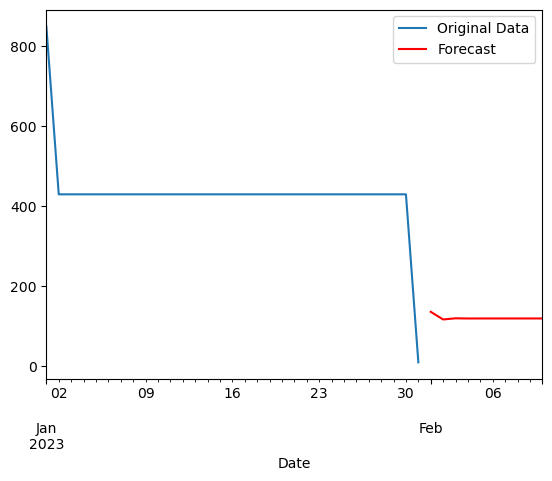

In [26]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Load the cleaned data
file_path = r'F:\MLpractrice\stockmarket\work\DSE_STOCKS_merged_final_cleaned_filled.csv'
merged_data = pd.read_csv(file_path)

# Ensure 'Date' is datetime
merged_data['Date'] = pd.to_datetime(merged_data['Date'])

# Sort and remove duplicates
merged_data = merged_data.sort_values(by='Date').drop_duplicates(subset='Date')

# Setting 'Date' as index
merged_data.set_index('Date', inplace=True)

# Ensure the index frequency is set properly
merged_data = merged_data.asfreq('D')

# Feature engineering - Using only the 'Close' price for time series prediction
data = merged_data['Close']

# Handling missing values
data = data.fillna(data.mean())

# Check stationarity and apply differencing if needed
adf_result = adfuller(data)
if adf_result[1] > 0.05:
    data = data.diff().dropna()

# Train ARIMA model on the time series data
arima_model = ARIMA(data, order=(1, 1, 1))
arima_result = arima_model.fit()

# Predicting future stock prices
future_predictions = arima_result.get_forecast(steps=10).predicted_mean
print("Future Predictions:")
print(future_predictions)

# Visualizing the results
import matplotlib.pyplot as plt

data.plot(label='Original Data')
future_predictions.plot(label='Forecast', color='red')
plt.legend()
plt.show()
